In [38]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from T_method import LayeredStructure
from My_plotter import Plotter, Style
from Global_optimizer import my_json_load #Проверка связи

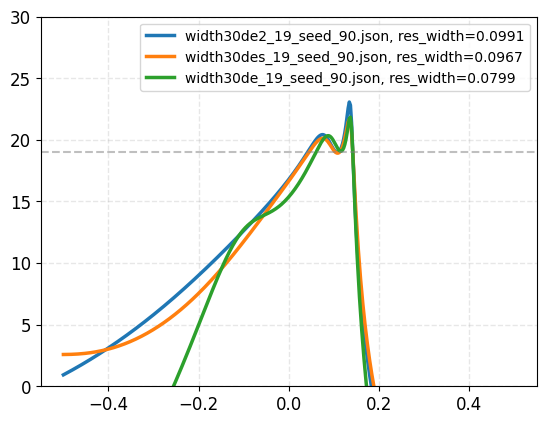

In [51]:
st = Style()
fig, ax = plt.subplots()
pl = Plotter(ax, st)
df = np.linspace(-50, 50, 400)/100
folder_path = Path('results/test')
for fpath in folder_path.iterdir():
    data = my_json_load(fpath)
    seed = data['de_seed']
    thres = data['sigma_thres']
    width = data['segment_width_percent']
    alpha = data["best_alpha"]
    beta = data["best_beta"]
    structure = LayeredStructure(alpha, beta=beta)
    directivity = 10*np.log10(structure.directivity(df))
    ##
    l = 0
    while directivity[l] < thres:
        l += 1
    r = len(directivity)-1
    while directivity[r] < thres:
        r -= 1
    res_width = (df[r] - df[l])*2/(df[r] + df[l] + 2)
    ##
    pl.plot(df, directivity, label=f"{fpath.name}, res_width={res_width:.4f}")
pl.finalize()
pl.set_ylim((0, 30))
ax.axhline(19, color='gray', linestyle='--', alpha=0.5)
# ax.axhline(16, color='gray', linestyle='--', alpha=0.5)
# ax.axvline(-0.11, color='gray', linestyle='--', alpha=0.5)
# ax.axvline(0.15, color='gray', linestyle='--', alpha=0.5)
plt.show()

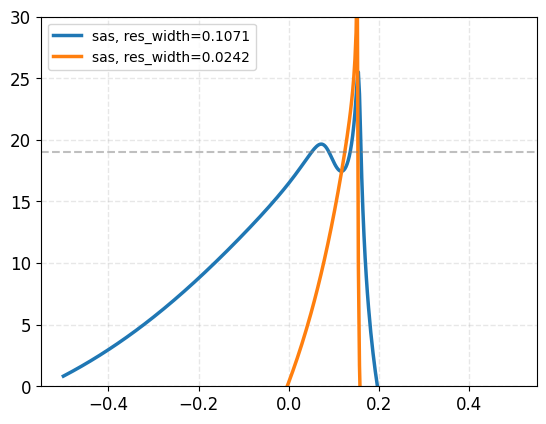

In [92]:
st = Style()
fig, ax = plt.subplots()
pl = Plotter(ax, st)
df = np.linspace(-50, 50, 400)/100
alpha_arr = []
beta_arr = []
alpha_arr.append([40, -5.5, 2.89])
beta_arr.append([2.7, 0.06, 2.4])
alpha_arr.append([40, -5.5, 2.89])
beta_arr.append([2.7, 2.0, 2.4])
for i in range(len(alpha_arr)):
    alpha = np.array(alpha_arr[i])
    beta = np.array(beta_arr[i])
    structure = LayeredStructure(alpha, beta=beta)
    directivity = 10*np.log10(structure.directivity(df))
    ##
    l = 0
    while directivity[l] < thres:
        l += 1
    r = len(directivity)-1
    while directivity[r] < thres:
        r -= 1
    res_width = (df[r] - df[l])*2/(df[r] + df[l] + 2)
    ##
    pl.plot(df, directivity, label=f"sas, res_width={res_width:.4f}")
pl.finalize()
pl.set_ylim((0, 30))
ax.axhline(19, color='gray', linestyle='--', alpha=0.5)
# ax.axhline(16, color='gray', linestyle='--', alpha=0.5)
# ax.axvline(-0.11, color='gray', linestyle='--', alpha=0.5)
# ax.axvline(0.15, color='gray', linestyle='--', alpha=0.5)
plt.show()